# Diabetes Risk Prediction - Análise e Classificação de dados usando Scikit-Learn, Pandas e Seaborn.

por Pedro Arthur Gomes Maia

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Bibliotecas importadas")

Bibliotecas importadas


Importando o dataset.

In [4]:
data = pd.read_csv("diabetes_risk.csv")
print("Dataset importado")

Dataset importado


# Análise e Exploração dos Dados

In [5]:
data.shape

(15000, 19)

In [6]:
data.columns

Index(['patient_id', 'age', 'gender', 'city', 'bmi', 'family_history_diabetes',
       'physical_activity_level', 'diet_type', 'smoking_status',
       'alcohol_consumption', 'hours_sleep_per_night', 'stress_level',
       'fasting_blood_sugar', 'hba1c_level', 'blood_pressure_systolic',
       'blood_pressure_diastolic', 'waist_circumference_cm', 'income_bracket',
       'diabetes_risk'],
      dtype='str')

In [24]:
numeric = data.select_dtypes(include=["number"]).columns
categorical = data.select_dtypes(exclude=["number"]).columns

print("Numéricas: ")
print(numeric)

print("Categóricas: ")
print(categorical)

Numéricas: 
Index(['age', 'bmi', 'hours_sleep_per_night', 'stress_level',
       'fasting_blood_sugar', 'hba1c_level', 'blood_pressure_systolic',
       'blood_pressure_diastolic', 'waist_circumference_cm'],
      dtype='str')
Categóricas: 
Index(['gender', 'city', 'family_history_diabetes', 'physical_activity_level',
       'diet_type', 'smoking_status', 'alcohol_consumption', 'income_bracket',
       'diabetes_risk'],
      dtype='str')


In [25]:
data.head(10)

,age,gender,city,bmi,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm,income_bracket,diabetes_risk
0,47,Female,Mumbai,26.5,Yes,Sedentary,Vegetarian,Never,Never,9.0,8,178,7.3,146,90,107.1,High,Low
1,53,Female,Mumbai,20.5,Yes,Moderate,Vegetarian,Never,Never,7.0,6,152,6.9,156,100,93.8,Low,Low
2,47,Male,Thane,31.3,No,Moderate,Non-Vegetarian,Current,Regular,7.0,7,168,6.6,150,102,113.5,Low,High
3,41,Male,Bengaluru,22.8,No,Sedentary,Non-Vegetarian,Never,Never,9.0,5,155,6.7,126,92,109.6,Middle,Low
4,57,Female,Bengaluru,16.7,No,Sedentary,Non-Vegetarian,Current,Occasional,6.5,10,188,6.7,130,90,80.8,High,Low
5,58,Male,Hyderabad,22.0,No,Active,Non-Vegetarian,Never,Occasional,6.9,6,148,6.3,148,100,98.0,High,Low
7,42,Female,Delhi,19.5,No,Active,Non-Vegetarian,Never,Never,6.0,7,270,8.9,136,80,89.9,Middle,High
8,57,Male,Mumbai,20.3,Yes,Moderate,Non-Vegetarian,Current,Never,4.8,10,186,7.4,170,91,92.3,High,Moderate
9,44,Male,Mumbai,24.1,No,Moderate,Non-Vegetarian,Current,Occasional,6.2,8,178,7.6,150,90,102.5,High,Moderate
10,51,Male,Kolkata,21.5,No,Moderate,Non-Vegetarian,Never,Occasional,10.0,2,139,6.5,130,80,99.6,Middle,Low


In [8]:
data.describe()

,patient_id,age,bmi,hours_sleep_per_night,stress_level,fasting_blood_sugar,hba1c_level,blood_pressure_systolic,blood_pressure_diastolic,waist_circumference_cm
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,7500.500000,44.333667,23.062260,7.309860,5.941200,168.789933,6.878387,139.496200,86.256933,100.207933
std,4330.271354,10.383753,4.046391,1.109372,2.148406,38.365822,0.843276,12.660785,8.386529,10.760331
min,1.000000,18.000000,15.000000,3.000000,1.000000,72.000000,4.800000,80.000000,50.000000,73.200000
25%,3750.750000,38.000000,20.100000,6.700000,4.000000,145.000000,6.300000,130.000000,80.000000,92.500000
50%,7500.500000,45.000000,22.700000,7.000000,6.000000,165.000000,6.800000,140.000000,88.000000,99.300000
75%,11250.250000,52.000000,25.600000,8.000000,7.000000,189.000000,7.300000,150.000000,90.000000,106.900000
max,15000.000000,80.000000,40.800000,12.000000,10.000000,400.000000,13.400000,200.000000,120.000000,148.200000


In [9]:
data.describe(include=['object'])

/tmp/ipykernel_1983/1736911641.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  data.describe(include=['object'])


,gender,city,family_history_diabetes,physical_activity_level,diet_type,smoking_status,alcohol_consumption,income_bracket,diabetes_risk
count,15000,15000,15000,15000,15000,14528,11212,14537,15000
unique,3,18,2,3,4,3,3,3,3
top,Male,Mumbai,No,Active,Non-Vegetarian,Never,Never,Middle,Low
freq,7664,2243,9756,5100,8195,10119,5616,7305,9000


In [41]:
# Checando se há linhas com dados faltando, ou dados duplicados.
print(data.isna().sum())
print(data.duplicated().sum())

age                         0
gender                      0
city                        0
bmi                         0
family_history_diabetes     0
physical_activity_level     0
diet_type                   0
smoking_status              0
alcohol_consumption         0
hours_sleep_per_night       0
stress_level                0
fasting_blood_sugar         0
hba1c_level                 0
blood_pressure_systolic     0
blood_pressure_diastolic    0
waist_circumference_cm      0
income_bracket              0
diabetes_risk               0
dtype: int64
0


Para lidar com as colunas sem valor, irei apenas desconsiderar as linhas com esses valores, já que esse dataset será utilizado para treinar alguns modelos de classificação.

Além disso, irei desconsiderar a coluna "patient_id", pois pode ser apenas representada pelo index da coluna.

In [11]:
data = data.dropna()
data = data.drop(columns=["patient_id"])
print(data.shape)

(10500, 18)


Analisando a distribuição dos dados.

In [13]:
sns.set_style("darkgrid")

Qual é a distribuição do risco de ter diabetes?

Porcentagens: 
Baixo: 60.02%
Moderado: 25.05%
Alto: 14.93%


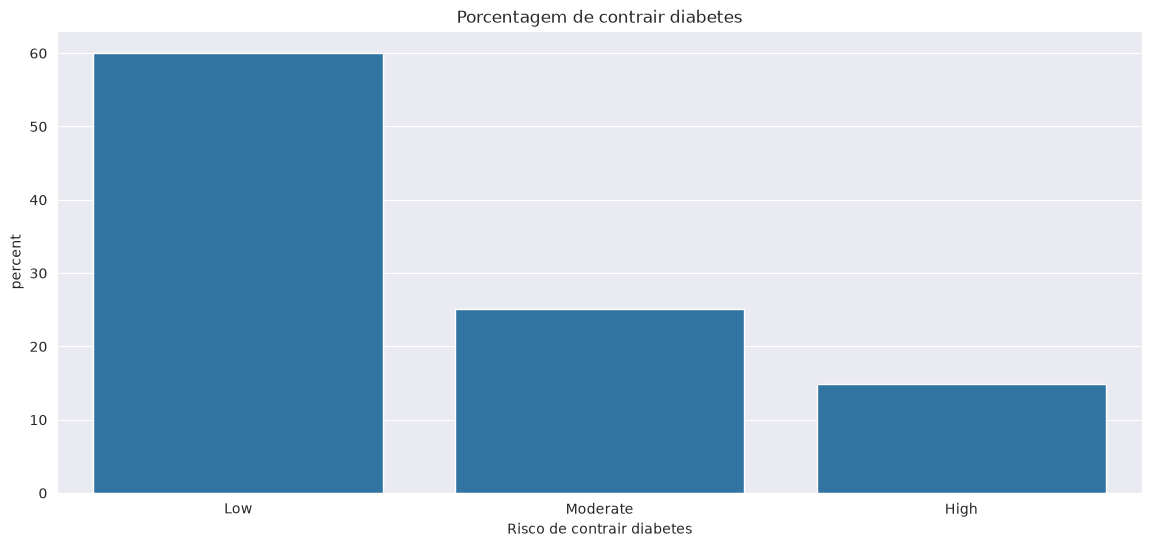

In [38]:
plt.figure(figsize=(14, 6))
plt.title("Porcentagem de contrair diabetes")

ax = sns.countplot(data=data, x="diabetes_risk", stat="percent", order=data["diabetes_risk"].value_counts().index)
ax.set_xlabel("Risco de contrair diabetes")

high = (data["diabetes_risk"] == "High").sum()
moderate = (data["diabetes_risk"] == "Moderate").sum()
low = (data["diabetes_risk"] == "Low").sum()

print("Porcentagens: ")
print(f"Baixo: {(low / data.shape[0]) * 100:.2f}%")
print(f"Moderado: {(moderate / data.shape[0]) * 100:.2f}%")
print(f"Alto: {(high / data.shape[0]) * 100:.2f}%")


Como é a distribuição das variáveis categóricas?

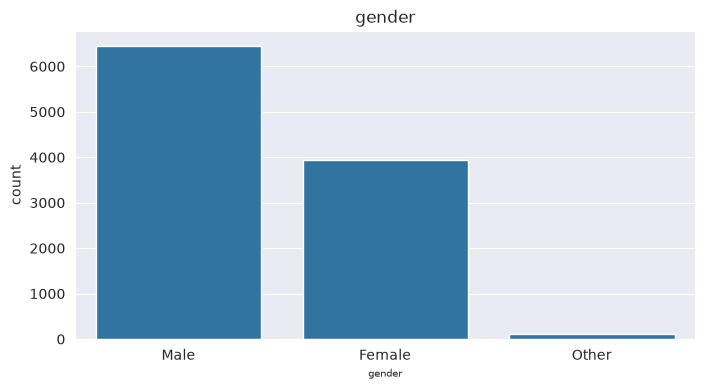

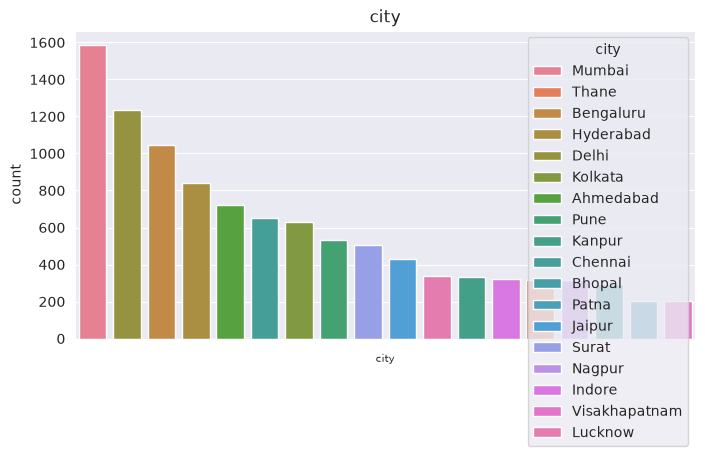

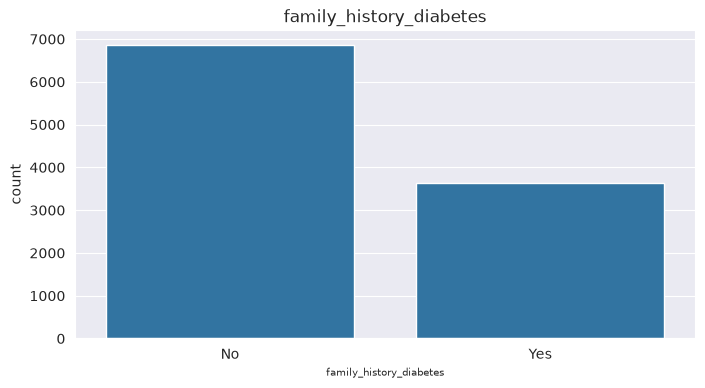

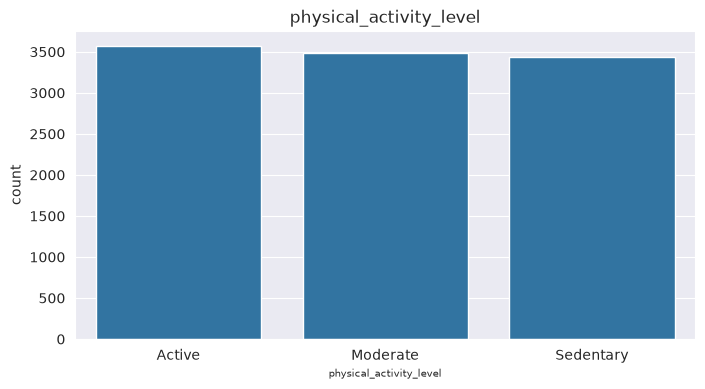

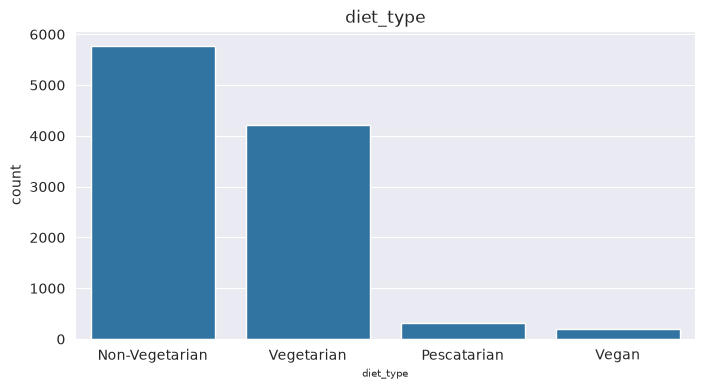

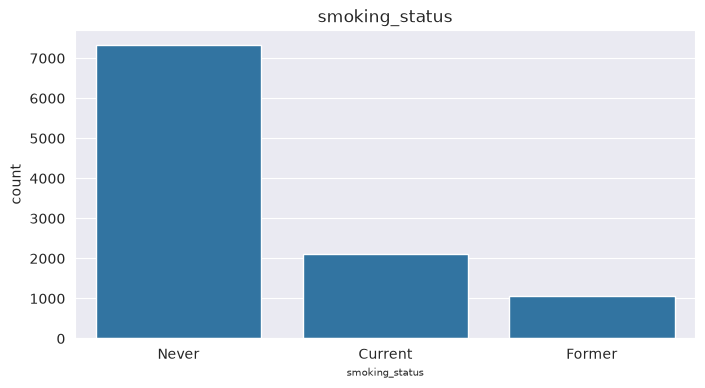

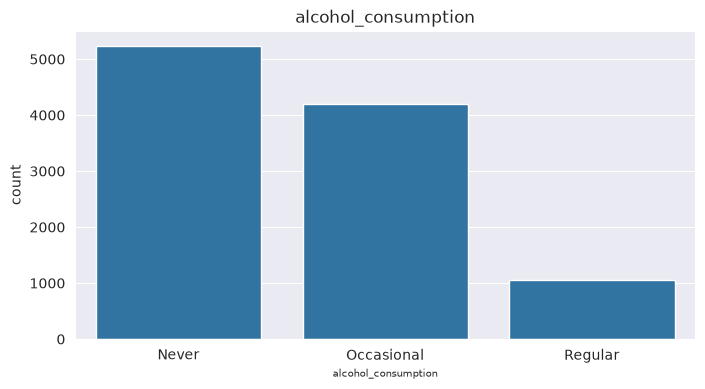

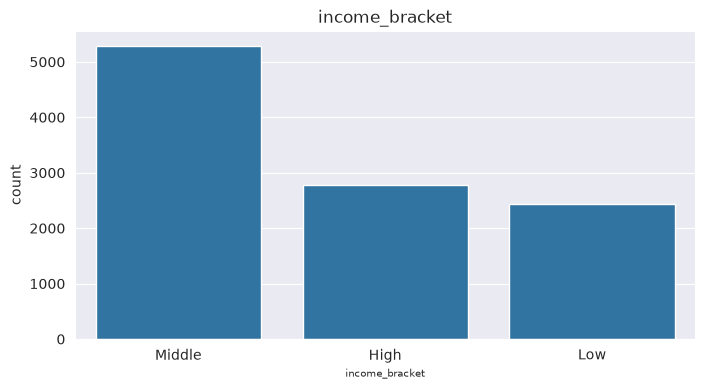

In [ ]:
categorical = data.select_dtypes(exclude=["number"])
N_GRAFICOS = categorical.shape[1]
for col in categorical.columns:
    if col != "diabetes_risk":
        plt.figure(figsize=(8, 4))
        plt.title(col)
        if col == "city":
            ax = sns.countplot(data=data, x=col, hue=col, order=data[col].value_counts().index, legend=True, stat="percent")
            ax.set_xticklabels([])
        else:
            ax = sns.countplot(data=data, x=col, order=data[col].value_counts().index, stat="percent")

        ax.set_xlabel(col, fontsize=7)

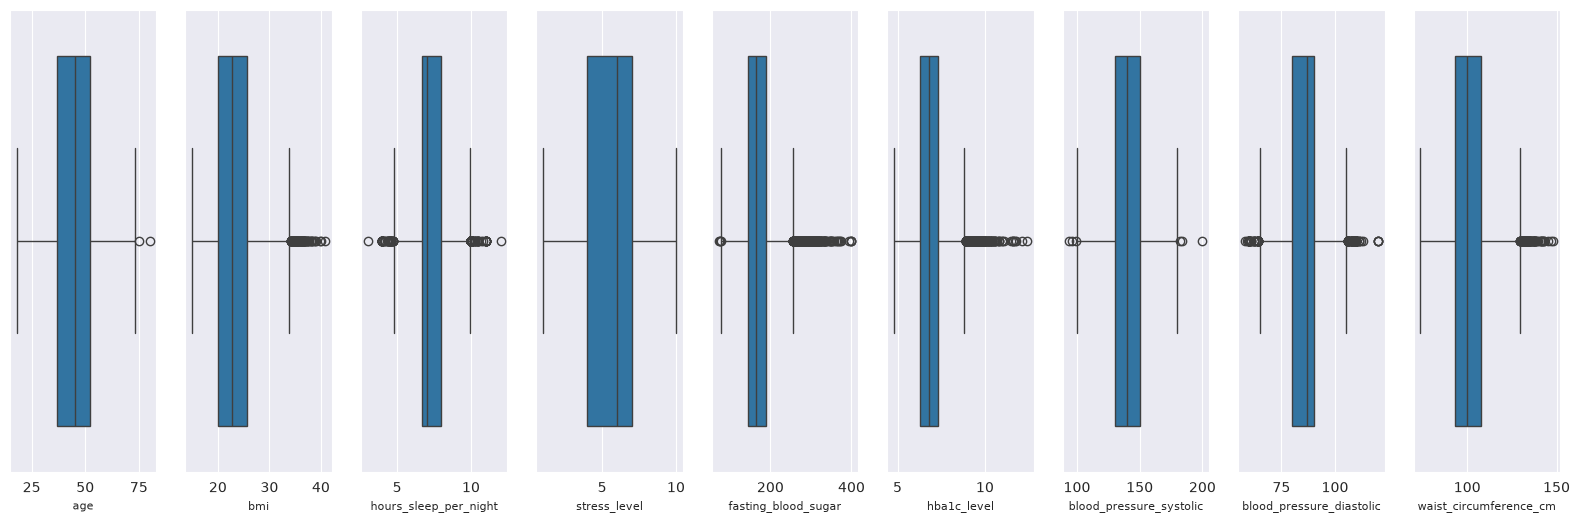

In [14]:
numeric = data.select_dtypes(include=["number"])
N_GRAFICOS = numeric.shape[1]
fig, axes = plt.subplots(ncols=N_GRAFICOS, figsize=(20, 6))
for id, col in enumerate(numeric.columns, 0):
    ax = sns.boxplot(data=data, x=col, ax = axes[id])
    ax.set_xlabel(col, fontsize=8)

Pelos resultados do gráfico, algumas colunas possuem alguns outliers, como "fasting_blood_sugar" e "hba1c_level", e outras são bem distribuídas, como "age" e "stress_level", que vai apenas de 0 a 10.

A colunas "bmi" e "hba1c_level" estão mais concentradas para a esquerda, já as outras estão mais concentradas no meio do gráfico.

<Axes: title={'center': 'Matriz de correlação'}>

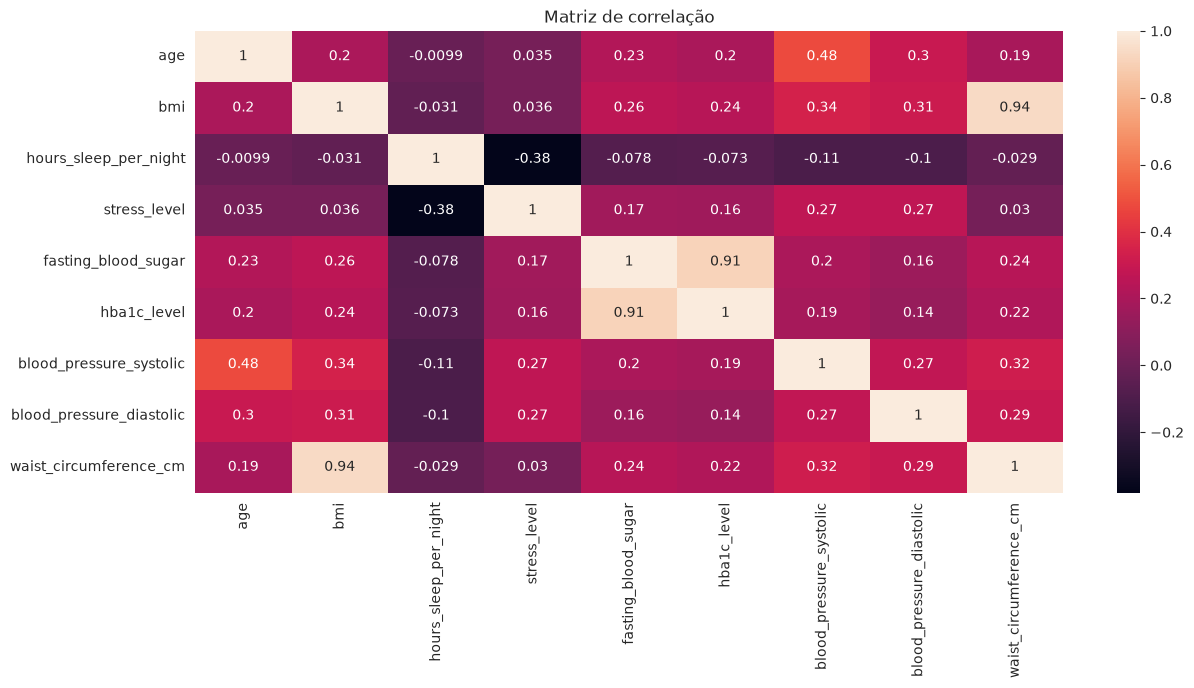

In [16]:
corr_matrix = data.corr(numeric_only=True)
plt.figure(figsize=(14, 6))
plt.title("Matriz de correlação")
sns.heatmap(corr_matrix, annot=True)

Existem algumas correlações bem claras, como uma relação inversamente proporcional entre o nível de estresse e as horas dormidas e a circunferência da cintura com o indíce de massa corporal (bmi).